# 🚀 SEMAINES 4-5 : Modèles Avancés et Gestion du Déséquilibre

**Projet:** Détection précoce DT1 - Cameroun  
**Objectifs:**
- Entraîner des algorithmes avancés (XGBoost, LightGBM)
- Gérer le déséquilibre des classes (SMOTE, class_weight)
- Optimiser les hyperparamètres
- Comparer avec les modèles de base

**Durée estimée:** 20-24 heures

---

In [6]:
# Import des bibliothèques
!pip install xgboost lightgbm imbalanced-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
print("✅ Bibliothèques importées!")

✅ Bibliothèques importées!


In [13]:
# Charger et préparer les données
df = pd.read_csv('../2_DONNEES/processed/dataset_clean.csv')
features = ['age', 'IMC', 'glycemie_jeun', 'HbA1c', 'ANP32A_IT1', 'ESCO2', 'NBPF1']
X = df[features]
y = df['diagnostic']

# Division train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"📂 Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"   Déséquilibre classes: {y_train.value_counts().to_dict()}")
print(f"   Ratio DT1/Total: {y_train.mean()*100:.1f}%")

📂 Train: 800 | Test: 200
   Déséquilibre classes: {0: 600, 1: 200}
   Ratio DT1/Total: 25.0%


Train: 600 | Val: 200 | Test: 200


## 🔥 Partie 1 : XGBoost (Extreme Gradient Boosting)

XGBoost = algorithme de boosting très performant, champion de Kaggle.

In [14]:
print("🔥 XGBOOST - Version de base\n")

# Modèle XGBoost de base
xgb_base = XGBClassifier(
    n_estimators=100, # Nombre d'arbres de décision à créer dans l'ensemble
    max_depth=6, # Profondeur maximale de chaque arbre
    learning_rate=0.1, # Taux d'apprentissage (eta) : contrôle la contribution de chaque arbre
    random_state=42,# Graine aléatoire pour la reproductibilité des résultats
    eval_metric='logloss'  # Métrique utilisée pendant l'entraînement pour calculer la perte
)
xgb_base.fit(X_train, y_train) # Le modèle apprend les relations entre X_train (features) et y_train (labels)

# Prédictions
y_pred_xgb = xgb_base.predict(X_test)
y_proba_xgb = xgb_base.predict_proba(X_test)[:, 1] #Génération des probabilités prédites pour l'ensemble de test

# Métriques
print(f"Accuracy:  {accuracy_score(y_test, y_pred_xgb)*100:.2f}%")# Proportion de prédictions correctes parmi toutes les prédictions
print(f"Precision: {precision_score(y_test, y_pred_xgb)*100:.2f}%")# Parmi tous les cas prédits comme diabétiques, quelle proportion l'est vraiment ?
print(f"Recall:    {recall_score(y_test, y_pred_xgb)*100:.2f}%  ⭐")# Parmi tous les vrais diabétiques, quelle proportion a été correctement détectée ?
print(f"F1-score:  {f1_score(y_test, y_pred_xgb):.3f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_proba_xgb):.3f}")

print("\n📋 Rapport détaillé:")
print(classification_report(y_test, y_pred_xgb, target_names=['Sain', 'DT1']))

🔥 XGBOOST - Version de base

Accuracy:  99.50%
Precision: 98.04%
Recall:    100.00%  ⭐
F1-score:  0.990
AUC-ROC:   1.000

📋 Rapport détaillé:
              precision    recall  f1-score   support

        Sain       1.00      0.99      1.00       150
         DT1       0.98      1.00      0.99        50

    accuracy                           0.99       200
   macro avg       0.99      1.00      0.99       200
weighted avg       1.00      0.99      1.00       200



In [15]:
# XGBoost avec gestion du déséquilibre (scale_pos_weight)
print("🔥 XGBOOST - Avec scale_pos_weight\n")

# Calculer le ratio pour scale_pos_weight
n_neg = (y_train == 0).sum()  # Comptage du nombre d'échantillons de la classe négative (Sain = 0)
n_pos = (y_train == 1).sum() # Comptage du nombre d'échantillons de la classe positive (DT1 = 1)
scale_pos_weight = n_neg / n_pos

print(f"scale_pos_weight calculé: {scale_pos_weight:.2f}")

xgb_balanced = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,  # Gérer le déséquilibre
    random_state=42,
    eval_metric='logloss'
)
xgb_balanced.fit(X_train, y_train)

# Prédictions
y_pred_xgb_bal = xgb_balanced.predict(X_test)
y_proba_xgb_bal = xgb_balanced.predict_proba(X_test)[:, 1]

# Métriques
print(f"\nAccuracy:  {accuracy_score(y_test, y_pred_xgb_bal)*100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred_xgb_bal)*100:.2f}%")
print(f"Recall:    {recall_score(y_test, y_pred_xgb_bal)*100:.2f}%  ⭐ (amélioré?)")
print(f"F1-score:  {f1_score(y_test, y_pred_xgb_bal):.3f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_proba_xgb_bal):.3f}")

# Feature importance
importances = xgb_balanced.feature_importances_
feature_imp_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("\n🔍 Importance des features:")
print(feature_imp_df)

🔥 XGBOOST - Avec scale_pos_weight

scale_pos_weight calculé: 3.00

Accuracy:  99.50%
Precision: 98.04%
Recall:    100.00%  ⭐ (amélioré?)
F1-score:  0.990
AUC-ROC:   1.000

🔍 Importance des features:
         Feature  Importance
2  glycemie_jeun    0.517724
3          HbA1c    0.416400
5          ESCO2    0.029761
4     ANP32A_IT1    0.019229
6          NBPF1    0.007701
0            age    0.004984
1            IMC    0.004201


## ⚡ Partie 2 : LightGBM

LightGBM = version plus rapide et moins gourmande en mémoire que XGBoost.

In [16]:
print("⚡ LIGHTGBM\n")

# Calculer class_weight
class_weight = {0: 1, 1: scale_pos_weight}

lgbm = LGBMClassifier(
    n_estimators=100, 
    max_depth=6, 
    learning_rate=0.1,
    class_weight='balanced',  # Ou utiliser dictionnaire
    random_state=42,
    verbose=-1  # Silencieux
)
lgbm.fit(X_train, y_train)

# Prédictions
y_pred_lgbm = lgbm.predict(X_test)
y_proba_lgbm = lgbm.predict_proba(X_test)[:, 1]

# Métriques
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lgbm)*100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred_lgbm)*100:.2f}%")
print(f"Recall:    {recall_score(y_test, y_pred_lgbm)*100:.2f}%  ⭐")
print(f"F1-score:  {f1_score(y_test, y_pred_lgbm):.3f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_proba_lgbm):.3f}")

print("\n📋 Rapport détaillé:")
print(classification_report(y_test, y_pred_lgbm, target_names=['Sain', 'DT1']))

⚡ LIGHTGBM

Accuracy:  99.50%
Precision: 98.04%
Recall:    100.00%  ⭐
F1-score:  0.990
AUC-ROC:   1.000

📋 Rapport détaillé:
              precision    recall  f1-score   support

        Sain       1.00      0.99      1.00       150
         DT1       0.98      1.00      0.99        50

    accuracy                           0.99       200
   macro avg       0.99      1.00      0.99       200
weighted avg       1.00      0.99      1.00       200



## 🔄 Partie 3 : SMOTE (Synthetic Minority Over-sampling Technique)

SMOTE = génère des échantillons synthétiques de la classe minoritaire pour rééquilibrer.

In [17]:
print("🔄 RANDOM FOREST + SMOTE\n")

# Appliquer SMOTE sur le train set uniquement
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Avant SMOTE: {y_train.value_counts().to_dict()}")
print(f"Après SMOTE: {pd.Series(y_train_sm).value_counts().to_dict()}")
print(f"Taille train set: {len(X_train)} → {len(X_train_sm)}\n")

# Entraîner Random Forest sur données SMOTE
rf_smote = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_smote.fit(X_train_sm, y_train_sm)

# Prédictions (TOUJOURS sur test set ORIGINAL)
y_pred_rf_smote = rf_smote.predict(X_test)
y_proba_rf_smote = rf_smote.predict_proba(X_test)[:, 1]

# Métriques
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf_smote)*100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred_rf_smote)*100:.2f}%")
print(f"Recall:    {recall_score(y_test, y_pred_rf_smote)*100:.2f}%  ⭐")
print(f"F1-score:  {f1_score(y_test, y_pred_rf_smote):.3f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_proba_rf_smote):.3f}")

print("\n💡 SMOTE améliore généralement le Recall au détriment de la Precision")

🔄 RANDOM FOREST + SMOTE

Avant SMOTE: {0: 600, 1: 200}
Après SMOTE: {0: 600, 1: 600}
Taille train set: 800 → 1200

Accuracy:  100.00%
Precision: 100.00%
Recall:    100.00%  ⭐
F1-score:  1.000
AUC-ROC:   1.000

💡 SMOTE améliore généralement le Recall au détriment de la Precision


## 📊 Comparaison Complète

📊 COMPARAISON DES MODÈLES AVANCÉS

             Modèle  Accuracy  Precision  Recall  F1-score  AUC-ROC
0      XGBoost base     0.995       0.98     1.0      0.99      1.0
1  XGBoost balanced     0.995       0.98     1.0      0.99      1.0
2          LightGBM     0.995       0.98     1.0      0.99      1.0
3        RF + SMOTE     1.000       1.00     1.0      1.00      1.0

⭐ Meilleur Recall: XGBoost base (100.00%)


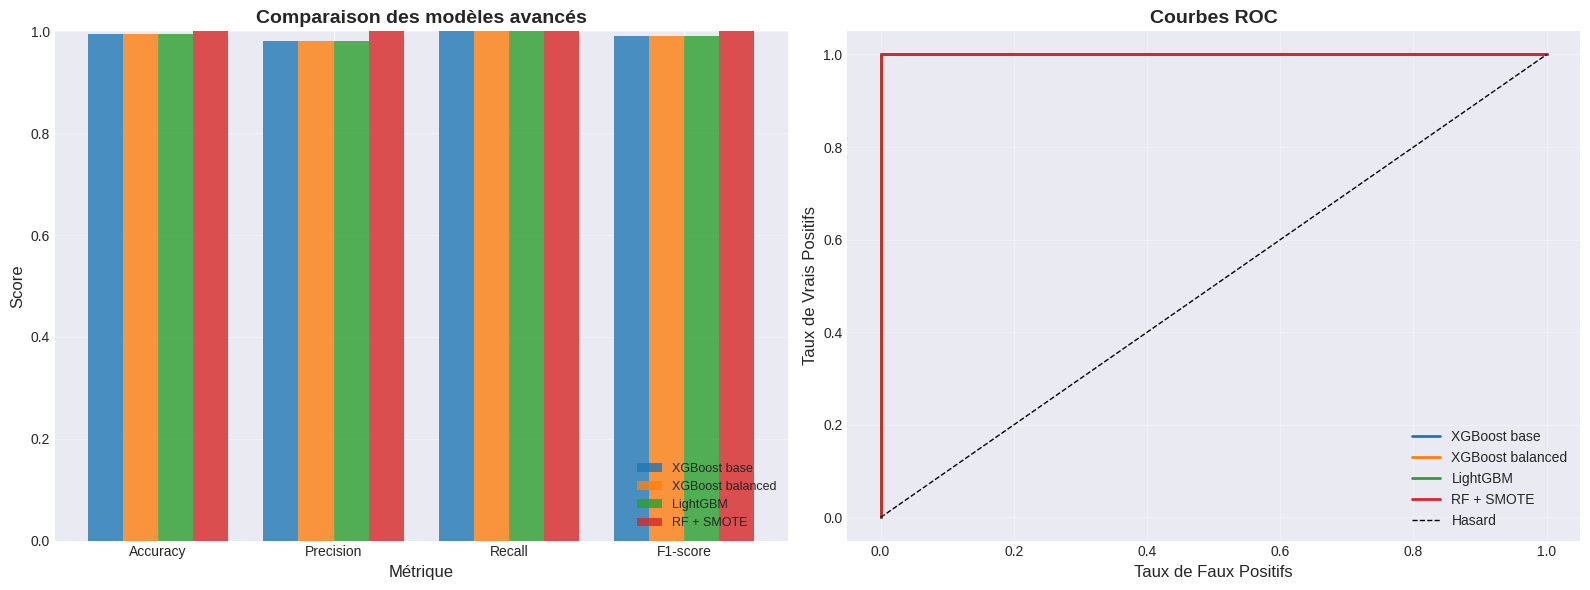

In [18]:
# Tableau comparatif
resultats = pd.DataFrame({
    'Modèle': ['XGBoost base', 'XGBoost balanced', 'LightGBM', 'RF + SMOTE'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_xgb_bal),
        accuracy_score(y_test, y_pred_lgbm),
        accuracy_score(y_test, y_pred_rf_smote)
    ],
    'Precision': [
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_xgb_bal),
        precision_score(y_test, y_pred_lgbm),
        precision_score(y_test, y_pred_rf_smote)
    ],
    'Recall': [
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_xgb_bal),
        recall_score(y_test, y_pred_lgbm),
        recall_score(y_test, y_pred_rf_smote)
    ],
    'F1-score': [
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_xgb_bal),
        f1_score(y_test, y_pred_lgbm),
        f1_score(y_test, y_pred_rf_smote)
    ],
    'AUC-ROC': [
        roc_auc_score(y_test, y_proba_xgb),
        roc_auc_score(y_test, y_proba_xgb_bal),
        roc_auc_score(y_test, y_proba_lgbm),
        roc_auc_score(y_test, y_proba_rf_smote)
    ]
})

print("📊 COMPARAISON DES MODÈLES AVANCÉS\n")
print(resultats.round(3))

# Meilleur Recall
best_idx = resultats['Recall'].idxmax()# Recherche de l'indice (index) de la ligne avec le meilleur Recall
print(f"\n⭐ Meilleur Recall: {resultats.loc[best_idx, 'Modèle']} ({resultats.loc[best_idx, 'Recall']*100:.2f}%)")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphique 1: Barres comparatives
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
x = np.arange(len(metrics))# Création des positions x pour les groupes de barres
width = 0.2  # Largeur de chaque barre individuelle divisé par le nombre de modèles pour qu'ils tiennent côte à côte

for i, (idx, row) in enumerate(resultats.iterrows()):
    axes[0].bar(x + i*width, row[metrics], width, label=row['Modèle'], alpha=0.8)

axes[0].set_xlabel('Métrique', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Comparaison des modèles avancés', fontsize=14, fontweight='bold')
axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(metrics)
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, 1)

# Graphique 2: Courbes ROC
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
fpr_xgb_bal, tpr_xgb_bal, _ = roc_curve(y_test, y_proba_xgb_bal)
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, y_proba_lgbm)
fpr_rf_sm, tpr_rf_sm, _ = roc_curve(y_test, y_proba_rf_smote)

axes[1].plot(fpr_xgb, tpr_xgb, linewidth=2, label='XGBoost base')
axes[1].plot(fpr_xgb_bal, tpr_xgb_bal, linewidth=2, label='XGBoost balanced')
axes[1].plot(fpr_lgbm, tpr_lgbm, linewidth=2, label='LightGBM')
axes[1].plot(fpr_rf_sm, tpr_rf_sm, linewidth=2, label='RF + SMOTE')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Hasard')

axes[1].set_xlabel('Taux de Faux Positifs', fontsize=12)
axes[1].set_ylabel('Taux de Vrais Positifs', fontsize=12)
axes[1].set_title('Courbes ROC', fontsize=14, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 🎯 Conclusion

### Points clés:

1. **XGBoost et LightGBM** sont généralement plus performants que les modèles de base
2. **scale_pos_weight / class_weight** améliore le Recall (capture plus de DT1)
3. **SMOTE** est efficace mais peut générer du sur-apprentissage
4. **Trade-off Precision/Recall:** À ajuster selon le contexte clinique

### Recommandation:
Sélectionner le modèle avec le meilleur **Recall** tout en maintenant une **Precision acceptable** (> 70%).

### 📅 Prochaine étape:
**Semaine 6:** Optimisation des hyperparamètres (GridSearch, validation croisée)

---

*Notebook créé pour le projet DT1 Cameroun - Master 2 Biophysique - 2025*